In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from funciones import derivadas, a_cartesiano

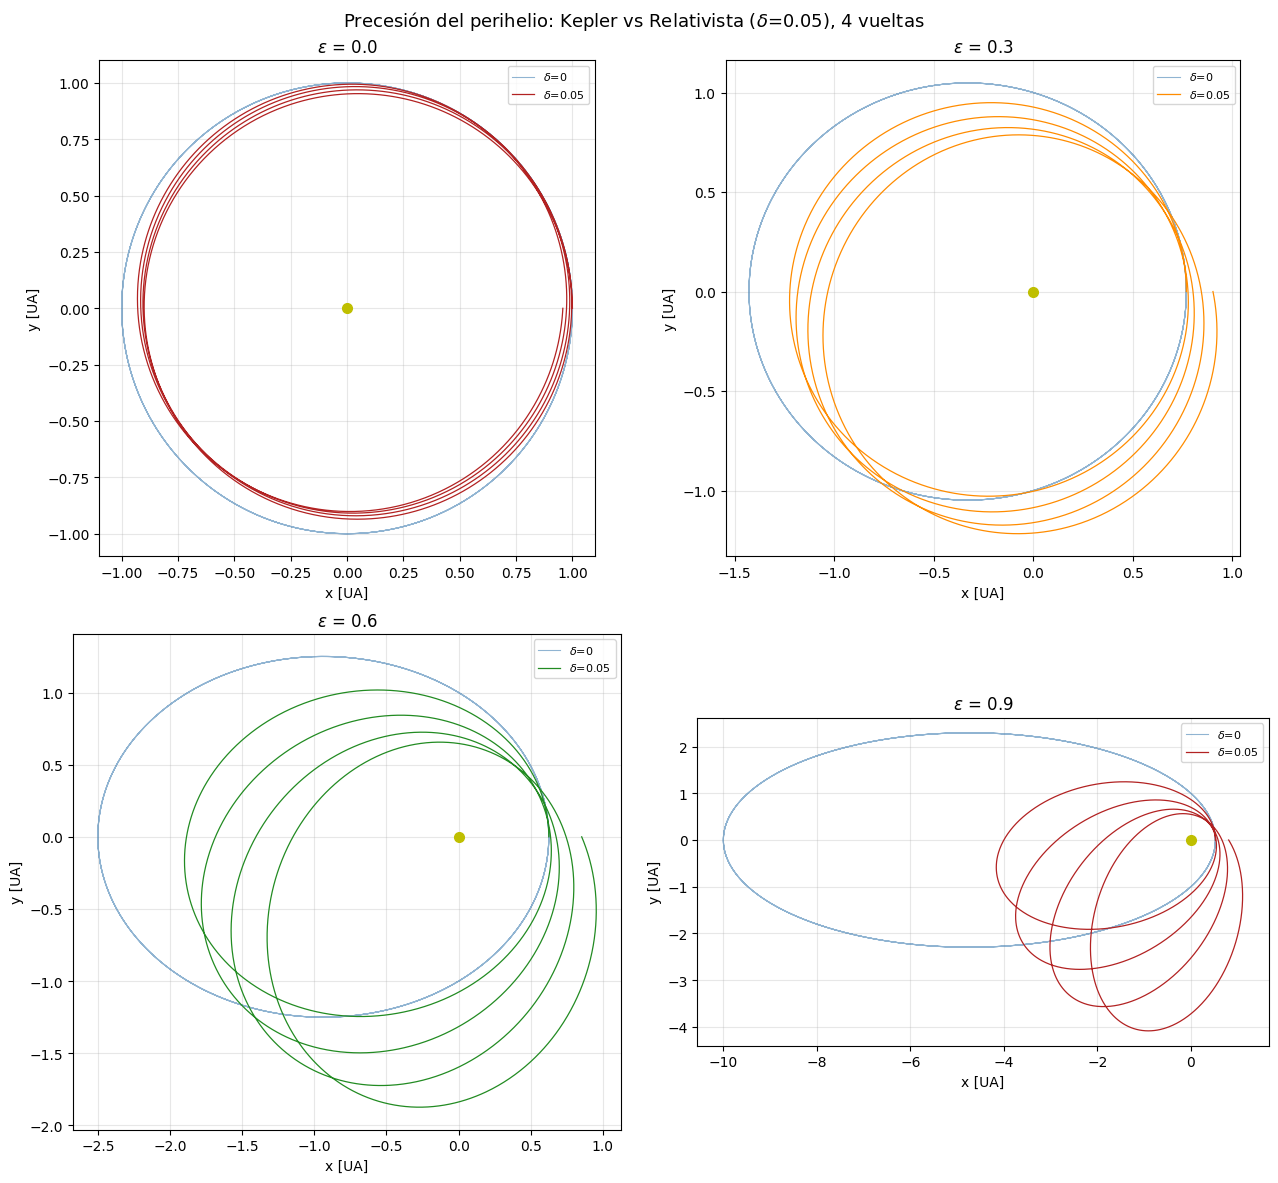

Precesion del perihelio por vuelta (formula analitica):
  Delta_phi = 2*pi*delta/alpha = 0.3142 rad = 18.0 grados


In [3]:
delta_rel = 0.05

ti_rel = 0.0
tf_rel = 4 * 2 * np.pi
lt_rel = np.linspace(ti_rel, tf_rel, 5000)

alpha = 1.0
epsilons = [0.0, 0.3, 0.6, 0.9]
colores  = ['steelblue', 'darkorange', 'forestgreen', 'firebrick']

fig, axs = plt.subplots(2, 2, figsize=(13, 12))

for idx in range(len(epsilons)):
    eps   = epsilons[idx]
    color = colores[idx]

    estado_inicial = [(1 + eps) / alpha, 0.0]

    sol_k = solve_ivp(derivadas, [ti_rel, tf_rel], estado_inicial,
                      t_eval=lt_rel, args=(alpha, 0.0),
                      rtol=1e-9, atol=1e-11)
    xk_eps, yk_eps = a_cartesiano(sol_k.t, sol_k.y[0])

    sol_r = solve_ivp(derivadas, [ti_rel, tf_rel], estado_inicial,
                      t_eval=lt_rel, args=(alpha, delta_rel),
                      rtol=1e-9, atol=1e-11)
    xr2, yr2 = a_cartesiano(sol_r.t, sol_r.y[0])

    fila = idx // 2
    col  = idx % 2
    ax   = axs[fila][col]

    rel_color = 'firebrick' if color == 'steelblue' else color

    ax.set_aspect(1.0)
    ax.plot(xk_eps, yk_eps, 'steelblue', lw=0.8, alpha=0.6, label=r'$\delta$=0')
    ax.plot(xr2,    yr2,    color=rel_color, lw=0.9,        label=r'$\delta$=0.05')
    ax.plot(0, 0, 'yo', ms=7, zorder=5)
    ax.set_title(r'$\varepsilon$ = ' + str(eps))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x [UA]')
    ax.set_ylabel('y [UA]')

fig.suptitle(r'Precesión del perihelio: Kepler vs Relativista ($\delta$=0.05), 4 vueltas', fontsize=13)
plt.tight_layout()
plt.savefig(r'graficos\figura_7_precesion_perihelio_kepler_vs_relativista.png', dpi=120, bbox_inches='tight')
plt.show()

precesion_rad    = 2 * np.pi * delta_rel / alpha
precesion_grados = np.degrees(precesion_rad)
print('Precesion del perihelio por vuelta (formula analitica):')
print('  Delta_phi = 2*pi*delta/alpha =', round(precesion_rad, 4), 'rad =', round(precesion_grados, 2), 'grados')